<a href="https://colab.research.google.com/github/Jerefilms/DEEP-LEARNING/blob/main/percepcion%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PRÁCTICA COMPLETA: RESOLUCIÓN DE EJERCICIOS CON OPENCV
# Asignatura: Percepción Computacional
# Universidad de Cundinamarca
# ==============================================================================

# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
# Descomenta la siguiente línea si necesitas instalar OpenCV en tu entorno de Colab:
# !pip install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

print("Versión de OpenCV:", cv2.__version__)
print("Versión de NumPy:", np.__version__)

Versión de OpenCV: 5.0.0
Versión de NumPy: 2.1.3


In [4]:
# ------------------------------------------------------------------------------
# FUNCIONES AUXILIARES (Visualización y respaldo)
# ------------------------------------------------------------------------------
def mostrar(imagen, titulo="Imagen"):
    """Función para mostrar imágenes correctamente usando Matplotlib."""
    plt.figure(figsize=(6, 6))
    if len(imagen.shape) == 3:
        # OpenCV lee en BGR, se convierte a RGB para visualizar correctamente
        img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(imagen, cmap="gray")
    plt.title(titulo)
    plt.axis("off")
    plt.show()

def crear_imagen_de_prueba():
    """Genera una imagen sintética de respaldo si el usuario no sube ninguna."""
    img_prueba = np.ones((400, 400, 3), dtype=np.uint8) * 255
    cv2.rectangle(img_prueba, (100, 100), (300, 300), (0, 0, 255), -1) # Cuadrado rojo
    cv2.circle(img_prueba, (200, 200), 50, (0, 255, 0), -1)           # Círculo verde
    cv2.imwrite("imagen_prueba.png", img_prueba)
    return "imagen_prueba.png"

In [6]:
# ------------------------------------------------------------------------------
# 3. INSPECCIÓN DE LA IMAGEN COMO DATOS (MATRIZ)
# ------------------------------------------------------------------------------
# Aseguramos que la imagen y la ruta estén definidas.
# Si no lo están, creamos una de prueba usando la función auxiliar.
if 'ruta_imagen' not in locals() or 'img' not in locals():
    try:
        ruta_imagen = "imagen_prueba.png"
        if not os.path.exists(ruta_imagen):
            crear_imagen_de_prueba()
        img = cv2.imread(ruta_imagen)
    except NameError:
        # Si por alguna razón la función auxiliar no está cargada
        img_prueba = np.ones((400, 400, 3), dtype=np.uint8) * 255
        cv2.rectangle(img_prueba, (100, 100), (300, 300), (0, 0, 255), -1)
        cv2.circle(img_prueba, (200, 200), 50, (0, 255, 0), -1)
        cv2.imwrite("imagen_prueba.png", img_prueba)
        ruta_imagen = "imagen_prueba.png"
        img = img_prueba

print("\n--- INSPECCIÓN DE DATOS ---")
print("Ruta del archivo:", ruta_imagen)
print("Forma (Alto, Ancho, Canales):", img.shape)
print("Tipo de dato de los píxeles:", img.dtype)
print("Valor mínimo de intensidad:", img.min())
print("Valor máximo de intensidad:", img.max())

alto, ancho = img.shape[:2]
print("Alto:", alto)
print("Ancho:", ancho)
print("Valor del píxel central (BGR):", img[alto//2, ancho//2])


--- INSPECCIÓN DE DATOS ---
Ruta del archivo: imagen_prueba.png
Forma (Alto, Ancho, Canales): (400, 400, 3)
Tipo de dato de los píxeles: uint8
Valor mínimo de intensidad: 0
Valor máximo de intensidad: 255
Alto: 400
Ancho: 400
Valor del píxel central (BGR): [  0 255   0]


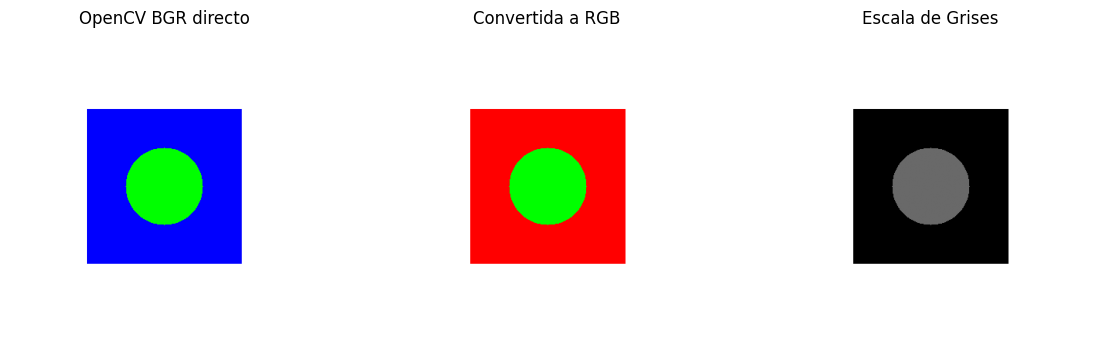

In [7]:
# ------------------------------------------------------------------------------
# 4. CONVERSIÓN DE COLOR (BGR -> RGB y Escala de Grises)
# ------------------------------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)  # Se ve con colores invertidos por estar en BGR nativo de OpenCV
plt.title("OpenCV BGR directo")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("Convertida a RGB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gris, cmap="gray")
plt.title("Escala de Grises")
plt.axis("off")
plt.show()

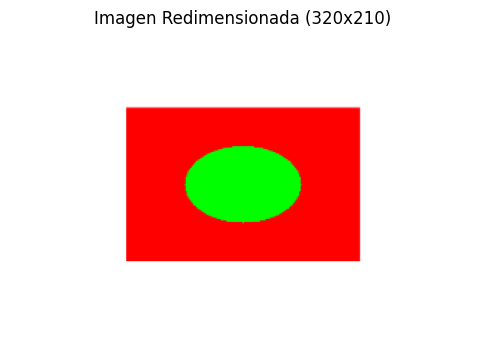

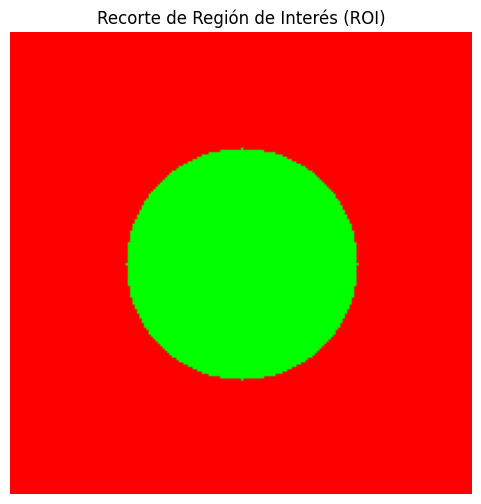


Dimensiones originales: (400, 400, 3)
Dimensiones redimensionadas: (210, 320, 3)
Dimensiones del recorte: (200, 200, 3)


In [8]:
# ------------------------------------------------------------------------------
# 5. REDIMENSIONAMIENTO Y RECORTE DE REGIONES DE INTERÉS (ROI)
# ------------------------------------------------------------------------------
redimensionada = cv2.resize(img, (320, 210))

# Recorte de la zona central (puedes ajustar los porcentajes a tu gusto)
y1, y2 = int(alto * 0.25), int(alto * 0.75)
x1, x2 = int(w := ancho * 0.25), int(ancho * 0.75) # Nota: w temporal
recorte = img[y1:y2, int(ancho*0.25):int(ancho*0.75)]

mostrar(redimensionada, "Imagen Redimensionada (320x210)")
mostrar(recorte, "Recorte de Región de Interés (ROI)")

print("\nDimensiones originales:", img.shape)
print("Dimensiones redimensionadas:", redimensionada.shape)
print("Dimensiones del recorte:", recorte.shape)

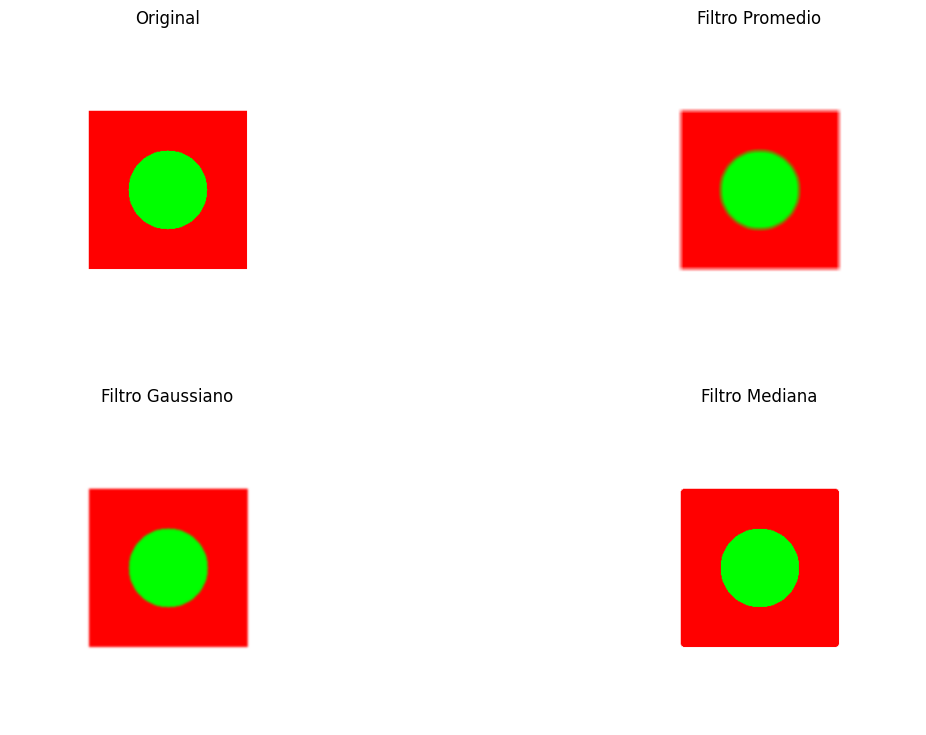

In [9]:
# ------------------------------------------------------------------------------
# 6. FILTRADO Y REDUCCIÓN DE RUIDO
# ------------------------------------------------------------------------------
blur_promedio = cv2.blur(img, (7, 7))
blur_gaussiano = cv2.GaussianBlur(img, (7, 7), 0)
blur_mediana = cv2.medianBlur(img, 7)

plt.figure(figsize=(14, 9))
filtros = [
    (img, "Original"),
    (blur_promedio, "Filtro Promedio"),
    (blur_gaussiano, "Filtro Gaussiano"),
    (blur_mediana, "Filtro Mediana")
]

for i, (im_f, titulo_f) in enumerate(filtros, 1):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(im_f, cv2.COLOR_BGR2RGB))
    plt.title(titulo_f)
    plt.axis("off")
plt.show()

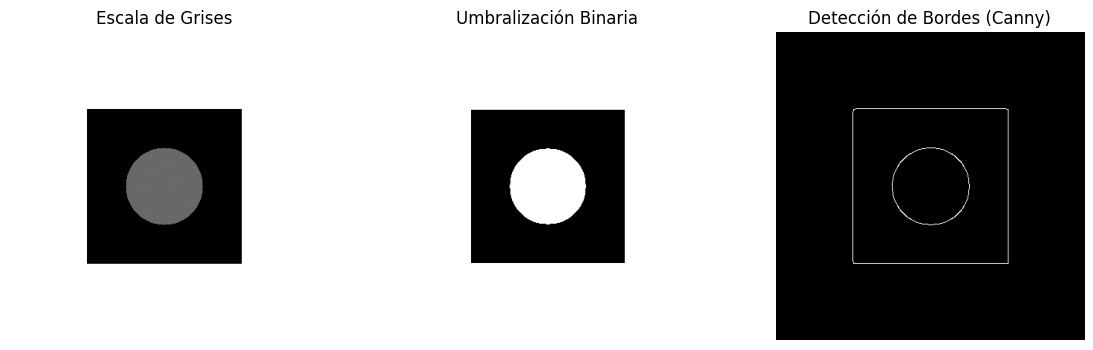

In [10]:
# ------------------------------------------------------------------------------
# 7. UMBRALIZACIÓN Y DETECCIÓN DE BORDES (CANNY)
# ------------------------------------------------------------------------------
gris_suave = cv2.GaussianBlur(gris, (5, 5), 0)
_, umbral = cv2.threshold(gris_suave, 127, 255, cv2.THRESH_BINARY)
bordes = cv2.Canny(gris_suave, 80, 160)

plt.figure(figsize=(14, 4))
procesamientos = [
    (gris, "Escala de Grises"),
    (umbral, "Umbralización Binaria"),
    (bordes, "Detección de Bordes (Canny)")
]

for i, (im_p, titulo_p) in enumerate(procesamientos, 1):
    plt.subplot(1, 3, i)
    plt.imshow(im_p, cmap="gray")
    plt.title(titulo_p)
    plt.axis("off")
plt.show()

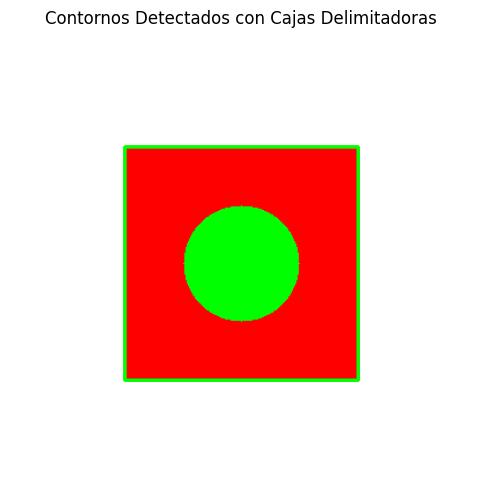


--- ANÁLISIS DE CONTORNOS ---
Cantidad total de contornos detectados: 1
Cantidad de contornos después del filtro (>100px): 1
Primeras áreas filtradas: [40390.0]

¡Proceso finalizado con éxito! Las imágenes de salida se guardaron en la carpeta 'resultados_opencv'.


In [11]:
# ------------------------------------------------------------------------------
# 8. EXTRACCIÓN DE CONTORNOS Y CAJAS DELIMITADORAS
# ------------------------------------------------------------------------------
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
resultado_contornos = img.copy()

areas_filtradas = []
for c in contornos:
    area = cv2.contourArea(c)
    if area > 100:  # Filtrar contornos pequeños (ruido)
        x, y, w_c, h_c = cv2.boundingRect(c)
        cv2.rectangle(resultado_contornos, (x, y), (x + w_c, y + h_c), (0, 255, 0), 2)
        areas_filtradas.append(area)

mostrar(resultado_contornos, "Contornos Detectados con Cajas Delimitadoras")
print("\n--- ANÁLISIS DE CONTORNOS ---")
print("Cantidad total de contornos detectados:", len(contornos))
print("Cantidad de contornos después del filtro (>100px):", len(areas_filtradas))
print("Primeras áreas filtradas:", areas_filtradas[:10])

# ------------------------------------------------------------------------------
# 9. GUARDAR RESULTADOS EN DISCO (Directorio local de Colab)
# ------------------------------------------------------------------------------
os.makedirs("resultados_opencv", exist_ok=True)
cv2.imwrite("resultados_opencv/01_original.png", img)
cv2.imwrite("resultados_opencv/02_gris.png", gris)
cv2.imwrite("resultados_opencv/03_redimensionada.png", redimensionada)
cv2.imwrite("resultados_opencv/04_recorte.png", recorte)
cv2.imwrite("resultados_opencv/05_blur_gaussiano.png", blur_gaussiano)
cv2.imwrite("resultados_opencv/06_umbral.png", umbral)
cv2.imwrite("resultados_opencv/07_bordes.png", bordes)
cv2.imwrite("resultados_opencv/08_contornos.png", resultado_contornos)

print("\n¡Proceso finalizado con éxito! Las imágenes de salida se guardaron en la carpeta 'resultados_opencv'.")